In [11]:
#!pip install findspark -q

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
#import functions/Classes for sparkml
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
from pyspark.ml.regression import LinearRegression

# import functions/Classes for metrics
from pyspark.ml.evaluation import RegressionEvaluator

In [13]:
import findspark
findspark.init()

In [14]:
#Create SparkSession

spark = SparkSession.builder.appName("Regressing using SparkML").getOrCreate()

In [ ]:
#Download data

#!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-BD0231EN-SkillsNetwork/datasets/mpg.csv

In [16]:
# Load mpg dataset
mpg_data = spark.read.csv("mpg.csv", header=True, inferSchema=True)

mpg_data.show())

+----+---------+-----------+----------+------+----------+----+--------+
| MPG|Cylinders|Engine Disp|Horsepower|Weight|Accelerate|Year|  Origin|
+----+---------+-----------+----------+------+----------+----+--------+
|15.0|        8|      390.0|       190|  3850|       8.5|  70|American|
|21.0|        6|      199.0|        90|  2648|      15.0|  70|American|
|18.0|        6|      199.0|        97|  2774|      15.5|  70|American|
|16.0|        8|      304.0|       150|  3433|      12.0|  70|American|
|14.0|        8|      455.0|       225|  3086|      10.0|  70|American|
|15.0|        8|      350.0|       165|  3693|      11.5|  70|American|
|18.0|        8|      307.0|       130|  3504|      12.0|  70|American|
|14.0|        8|      454.0|       220|  4354|       9.0|  70|American|
|15.0|        8|      400.0|       150|  3761|       9.5|  70|American|
|10.0|        8|      307.0|       200|  4376|      15.0|  70|American|
|15.0|        8|      383.0|       170|  3563|      10.0|  70|Am

In [17]:
mpg_data.printSchema()

root
 |-- MPG: double (nullable = true)
 |-- Cylinders: integer (nullable = true)
 |-- Engine Disp: double (nullable = true)
 |-- Horsepower: integer (nullable = true)
 |-- Weight: integer (nullable = true)
 |-- Accelerate: double (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Origin: string (nullable = true)



In [18]:
# Prepare feature vector
assembler = VectorAssembler(inputCols=["Cylinders", "Engine Disp", "Horsepower", "Weight", "Accelerate", "Year"], outputCol="features")
mpg_transformed_data = assembler.transform(mpg_data)

In [19]:
mpg_transformed_data.show()

+----+---------+-----------+----------+------+----------+----+--------+--------------------+
| MPG|Cylinders|Engine Disp|Horsepower|Weight|Accelerate|Year|  Origin|            features|
+----+---------+-----------+----------+------+----------+----+--------+--------------------+
|15.0|        8|      390.0|       190|  3850|       8.5|  70|American|[8.0,390.0,190.0,...|
|21.0|        6|      199.0|        90|  2648|      15.0|  70|American|[6.0,199.0,90.0,2...|
|18.0|        6|      199.0|        97|  2774|      15.5|  70|American|[6.0,199.0,97.0,2...|
|16.0|        8|      304.0|       150|  3433|      12.0|  70|American|[8.0,304.0,150.0,...|
|14.0|        8|      455.0|       225|  3086|      10.0|  70|American|[8.0,455.0,225.0,...|
|15.0|        8|      350.0|       165|  3693|      11.5|  70|American|[8.0,350.0,165.0,...|
|18.0|        8|      307.0|       130|  3504|      12.0|  70|American|[8.0,307.0,130.0,...|
|14.0|        8|      454.0|       220|  4354|       9.0|  70|American

In [20]:
# Display only the target and the features column

mpg_transformed_data.select("MPG", "features").show()

+----+--------------------+
| MPG|            features|
+----+--------------------+
|15.0|[8.0,390.0,190.0,...|
|21.0|[6.0,199.0,90.0,2...|
|18.0|[6.0,199.0,97.0,2...|
|16.0|[8.0,304.0,150.0,...|
|14.0|[8.0,455.0,225.0,...|
|15.0|[8.0,350.0,165.0,...|
|18.0|[8.0,307.0,130.0,...|
|14.0|[8.0,454.0,220.0,...|
|15.0|[8.0,400.0,150.0,...|
|10.0|[8.0,307.0,200.0,...|
|15.0|[8.0,383.0,170.0,...|
|11.0|[8.0,318.0,210.0,...|
|10.0|[8.0,360.0,215.0,...|
|15.0|[8.0,429.0,198.0,...|
|21.0|[6.0,200.0,85.0,2...|
|17.0|[8.0,302.0,140.0,...|
| 9.0|[8.0,304.0,193.0,...|
|14.0|[8.0,340.0,160.0,...|
|22.0|[6.0,198.0,95.0,2...|
|14.0|[8.0,440.0,215.0,...|
+----+--------------------+
only showing top 20 rows


In [21]:
# Split the data to train and test set

(training_data, test_data) = mpg_transformed_data.randomSplit([0.7, 0.3], seed=42)

In [22]:
# scaling

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures",
    withStd=True)

# Fit the scaler only on the training data
scaler_model = scaler.fit(training_data)

# Transform both training and test data using the fitted scaler
training_data_scaled = scaler_model.transform(training_data)
test_data_scaled = scaler_model.transform(test_data)

# Show a sample of the scaled training data
training_data_scaled.select("scaledFeatures", "MPG").show(5, truncate=False)

+----------------------------------------------------------------------------------------------------------------+----+
|scaledFeatures                                                                                                  |MPG |
+----------------------------------------------------------------------------------------------------------------+----+
|[4.824452749420509,3.059704189916983,5.269395825357557,5.8939591203580575,6.75735340832898,19.007586370216494]  |9.0 |
|[4.824452749420509,3.0898986391595846,5.460513808660681,5.4505420774908835,5.478935195942416,19.007586370216494]|10.0|
|[4.824452749420509,3.2006116197157914,5.733539499093715,5.458015398438083,4.931041676348174,19.007586370216494] |11.0|
|[4.824452749420509,3.5226857449702105,4.9144624277946125,4.563707991756535,4.017885810357772,19.822197214654345]|11.0|
|[4.824452749420509,4.0259265656802405,4.095385356495511,6.224030795526039,5.113672849546255,19.822197214654345] |11.0|
+---------------------------------------

In [23]:
# Train a Linear regression model

lr = LinearRegression(featuresCol="scaledFeatures", labelCol="MPG")
lr_model = lr.fit(training_data_scaled)

# This code is Spark-only: in PySpark ML, the model performs fit(training_data) on a DataFrame and uses featuresCol/labelCol
# to determine which columns to read. In scikit-learn, however, fit(X_train, y_train) requires separate features and targets
# (X and y), typically as arrays or pandas DataFrame/Series.

In [25]:
predictions = lr_model.transform(test_data_scaled)

In [26]:
evaluator = RegressionEvaluator(labelCol="MPG", predictionCol="prediction", metricName="r2")
r2 = evaluator.evaluate(predictions)
print("R Squared =", r2)

R Squared = 0.8046190375720694


In [27]:
# Convert predictions Spark DataFrame to Pandas DataFrame for easier plotting
predictions_pd = predictions.toPandas()

predictions_pd.head()

,MPG,Cylinders,Engine Disp,Horsepower,Weight,Accelerate,Year,Origin,features,scaledFeatures,prediction
0,10.0,8,360.0,215,4615,14.0,70,American,"[8.0, 360.0, 215.0, 4615.0, 14.0, 70.0]","[4.824452749420509, 3.6233339091122168, 5.8700...",6.683344
1,11.0,8,429.0,208,4633,11.0,72,American,"[8.0, 429.0, 208.0, 4633.0, 11.0, 72.0]","[4.824452749420509, 4.317806241692058, 5.67893...",8.344953
2,12.0,8,350.0,180,4499,12.5,73,American,"[8.0, 350.0, 180.0, 4499.0, 12.5, 73.0]","[4.824452749420509, 3.5226857449702105, 4.9144...",10.043421
3,12.0,8,383.0,180,4955,11.5,71,American,"[8.0, 383.0, 180.0, 4955.0, 11.5, 71.0]","[4.824452749420509, 3.8548246866388305, 4.9144...",5.252194
4,13.0,8,302.0,129,3169,12.0,75,American,"[8.0, 302.0, 129.0, 3169.0, 12.0, 75.0]","[4.824452749420509, 3.0395745570885815, 3.5220...",21.473697


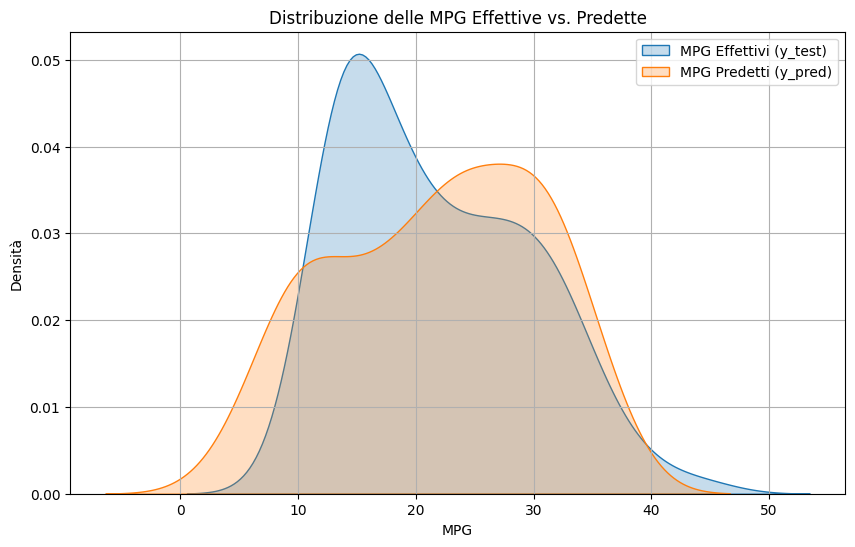

In [28]:

# Plot the distribution of actual MPG and predicted MPG as two curves
plt.figure(figsize=(10, 6))
sns.kdeplot(predictions_pd['MPG'], label='MPG Effettivi (y_test)', fill=True)
sns.kdeplot(predictions_pd['prediction'], label='MPG Predetti (y_pred)', fill=True)
plt.xlabel('MPG')
plt.ylabel('Densità')
plt.title('Distribuzione delle MPG Effettive vs. Predette')
plt.legend()
plt.grid(True)
plt.show()

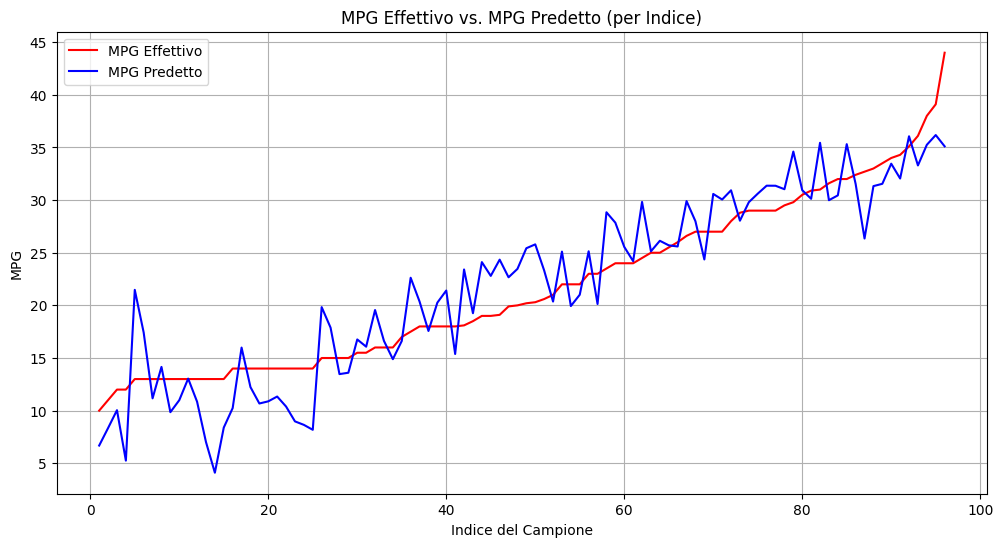

In [29]:
c = [i for i in range(1, len(predictions_pd) + 1)]

plt.figure(figsize=(12, 6)) # Increased figure size for better readability
plt.plot(c, predictions_pd['MPG'], color='r', linestyle='-', label='MPG Effettivo')
plt.plot(c, predictions_pd['prediction'], color='b', linestyle='-', label='MPG Predetto')
plt.xlabel('Indice del Campione') # Changed xlabel to reflect sample index
plt.ylabel('MPG')
plt.title('MPG Effettivo vs. MPG Predetto (per Indice)')
plt.legend() # Added legend to distinguish between actual and predicted
plt.grid(True) # Added grid for better readability
plt.show()

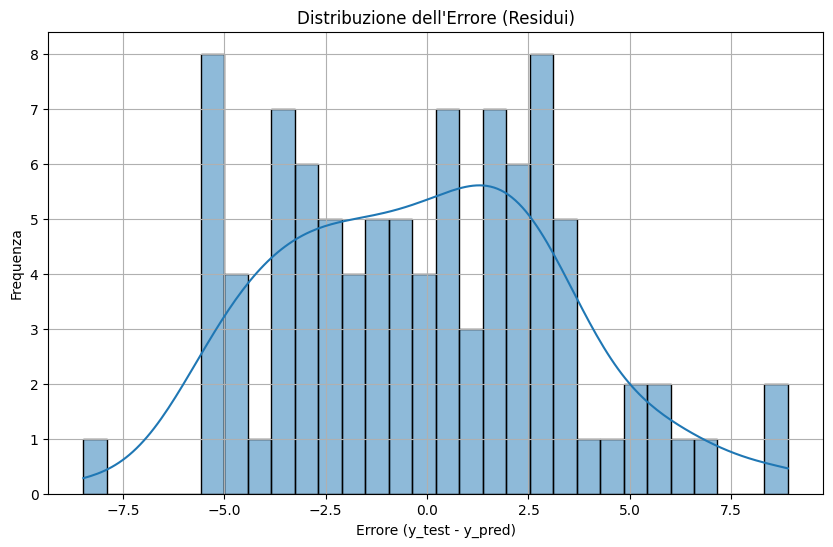

In [30]:
# Calcola l'errore (residui)
predictions_pd['error'] = predictions_pd['MPG'] - predictions_pd['prediction']

# Plot della distribuzione dell'errore (curva di errore)
plt.figure(figsize=(10, 6))
sns.histplot(predictions_pd['error'], kde=True, bins=30)
plt.xlabel('Errore (y_test - y_pred)')
plt.ylabel('Frequenza')
plt.title('Distribuzione dell\'Errore (Residui)')
plt.grid(True)
plt.show()